In [1]:
import sys
sys.path.append('/Users/shufay/Documents/ad_afqmc')

import h5py
from math import floor
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

from ad_afqmc.lattices import triangular_grid

In [2]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=16)
plt.rc('ytick',labelsize=16)
plt.rc('axes',labelsize=18)
plt.rc('axes',titlesize=18)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif']=cmfont.get_name()
mpl.rcParams['mathtext.fontset']='cm'
mpl.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())

In [3]:
def linear(x, m, c):
    return m*x + c

# Load data

## ny = 4

In [4]:
ny = 4
bc = 'yc'
v = 0.
dt = 0.005

nwalkers = 400
dt = 0.005
path = f'./data/cluster_{bc}_{ny}xL/'

U_arr = [4., 8., 12.]
df_cpmc_arr_4 = []
df_dmrg_arr_4 = []

for iU, U in enumerate(U_arr):
    print(iU, dt, nwalkers, U)
    try: 
        df_cpmc = pd.read_csv(f'{path}cpmc_U={U}_v={v}_dt={dt}_nwalkers={nwalkers}.csv')
        df_cpmc = df_cpmc.set_index('# nx')
        if 30.0 in df_cpmc.index: df_cpmc = df_cpmc.drop(30.0)
        df_cpmc_arr_4.append(df_cpmc)

    except: print(f'No CPMC results for U = {U}')

for iU, U in enumerate(U_arr):
    print(iU, U)

    try: 
        df_dmrg = pd.read_csv(f'{path}dmrg_extrap_U={U}_{bc}_{ny}xL.csv')
        df_dmrg = df_dmrg.set_index('nx')
        df_dmrg_arr_4.append(df_dmrg)

    except: print(f'No DMRG results for U = {U}')

0 0.005 400 4.0
1 0.005 400 8.0
2 0.005 400 12.0
0 4.0
1 8.0
2 12.0


In [5]:
ny = 4
bc = 'yc'
path = f'./data/cluster_{bc}_{ny}xL/'

npz_cpmc_4 = np.load(f'{path}cpmc_extrap_cluster_{bc}_{ny}xL.npz')

print(list(npz_cpmc_4))
print(list(npz_cpmc_4['e_infty']))
print(list(npz_cpmc_4['e_infty_toterr']))

['U', 'e_infty', 'e_infty_toterr', 'e_infty_syserr', 'e_infty_staterr']
[np.float64(-1.5835992780927315), np.float64(-1.4784046308297756), np.float64(-1.416513293482175)]
[np.float64(0.00012792323423981762), np.float64(0.0001680059996619264), np.float64(0.00016747218089844767)]


In [6]:
for iU, U in enumerate(U_arr):
    print(f'\ndt, nwalkers, U =  {dt, nwalkers, U}')
    try: print(df_cpmc_arr_4[iU])
    except: pass


dt, nwalkers, U =  (0.005, 400, 4.0)
       nup  ndown  n_walkers  n_eql  e_ghf      e_cpmc  err_cpmc     time  \
# nx                                                                        
4.0    4.0    4.0      400.0  200.0    0.0  -23.011761  0.000441    587.0   
8.0    8.0    8.0      400.0  200.0    0.0  -48.214319  0.000564    580.0   
12.0  12.0   12.0      400.0  200.0    0.0  -73.508823  0.000678    819.0   
16.0  16.0   16.0      400.0  200.0    0.0  -98.825265  0.000807   1450.0   
20.0  20.0   20.0      400.0  200.0    0.0 -124.154022  0.000807   2310.0   
24.0  24.0   24.0      400.0  200.0    0.0 -149.487864  0.000921   4070.0   
28.0  28.0   28.0      400.0  200.0    0.0 -174.822471  0.001208   6100.0   
36.0  36.0   36.0      400.0  200.0    0.0 -225.499391  0.001061  12300.0   
40.0  40.0   40.0      400.0   20.0    0.0 -250.837954  0.001116  10800.0   

     trial  Unnamed: 10  
# nx                     
4.0     fe          NaN  
8.0     fe          NaN  
12.0    fe

In [7]:
for iU, U in enumerate(U_arr):
    print(f'\nU =  {U}')
    try: print(df_dmrg_arr_4[iU])
    except: pass


U =  4.0
    nup  ndown  e_dmrg (last sweep)  extrap. maxerr -> 0   diff/Ns    % diff  \
nx                                                                             
8     8      8           -48.215147           -48.215334  0.000006  0.000388   
12   12     12           -73.504528           -73.509286  0.000099  0.006470   
16   16     16           -98.813188           -98.828449  0.000238  0.015400   
20   20     20          -124.126805          -124.168131  0.000517  0.033300   

    stat err   sys err  total err data points  
nx                                             
8   0.000003  0.000010   0.000010    last 3-5  
12  0.000204  0.000316   0.000376    last 3-5  
16  0.000515  0.000508   0.000723    last 3-5  
20  0.001000  0.001650   0.001930    last 3-5  

U =  8.0
    nup  ndown  e_dmrg (last sweep)  extrap. maxerr -> 0   diff/Ns    % diff  \
nx                                                                             
8     8      8           -44.898882           -44.8

## ny = 6

In [8]:
ny = 6
bc = 'yc'
v = 0.
dt = 0.005

nwalkers = 600
dt = 0.005
path = f'./data/cluster_{bc}_{ny}xL/'

U_arr = [4., 8., 12.]
df_cpmc_arr_6 = []
df_dmrg_arr_6 = []

trial = 'fe'

for iU, U in enumerate(U_arr):
    print(iU, dt, nwalkers, U)
    
    try: 
        df_cpmc = pd.read_csv(f'{path}cpmc_U={U}_v={v}_dt={dt}_nwalkers={nwalkers}.csv')
        df_cpmc = df_cpmc.set_index('# nx')
        df_cpmc = df_cpmc[df_cpmc['trial'] == trial]
        df_cpmc_arr_6.append(df_cpmc)

    except: print(f'No CPMC results for U = {U}')

for iU, U in enumerate(U_arr):
    print(iU, U)

    try: 
        df_dmrg = pd.read_csv(f'{path}dmrg_extrap_U={U}_{bc}_{ny}xL.csv')
        df_dmrg = df_dmrg.set_index('nx')
        df_dmrg_arr_6.append(df_dmrg)

    except: print(f'No DMRG results for U = {U}')

0 0.005 600 4.0
1 0.005 600 8.0
2 0.005 600 12.0
0 4.0
1 8.0
2 12.0


In [9]:
ny = 6
bc = 'yc'
path = f'./data/cluster_{bc}_{ny}xL/'

npz_cpmc_6 = np.load(f'{path}cpmc_extrap_cluster_{bc}_{ny}xL.npz')

print(list(npz_cpmc_6))
print(list(npz_cpmc_6['e_infty']))
print(list(npz_cpmc_6['e_infty_toterr']))

['U', 'e_infty', 'e_infty_toterr', 'e_infty_syserr', 'e_infty_staterr']
[np.float64(-1.6466308888641898), np.float64(-1.535625807177004), np.float64(-1.4690465781260922)]
[np.float64(0.0010499469571524113), np.float64(0.0010537042794702641), np.float64(0.0010971393254115282)]


In [10]:
for iU, U in enumerate(U_arr):
    print(f'\ndt, nwalkers, U =  {dt, nwalkers, U}')
    try: print(df_cpmc_arr_6[iU])
    except: pass


dt, nwalkers, U =  (0.005, 600, 4.0)
       nup  ndown  e_ghf      e_cpmc  err_cpmc     time trial  Unnamed: 8
# nx                                                                     
6.0    9.0    9.0    0.0  -55.441055  0.000453    849.0    fe         NaN
8.0   12.0   12.0    0.0  -74.976679  0.000524   1220.0    fe         NaN
10.0  15.0   15.0    0.0  -94.552478  0.000576   1760.0    fe         NaN
24.0  36.0   36.0    0.0 -232.689889  0.000872  11700.0    fe         NaN
26.0  39.0   39.0    0.0 -252.494044  0.000876  14300.0    fe         NaN
28.0  42.0   42.0    0.0 -272.271561  0.000873  17500.0    fe         NaN
30.0  45.0   45.0    0.0 -292.030633  0.000954  21500.0    fe         NaN
32.0  48.0   48.0    0.0 -311.771505  0.000974  26200.0    fe         NaN

dt, nwalkers, U =  (0.005, 600, 8.0)
       nup  ndown  e_ghf      e_cpmc  err_cpmc     time trial  Unnamed: 8
# nx                                                                     
6.0    9.0    9.0    0.0  -51.703563

In [11]:
for iU, U in enumerate(U_arr):
    print(f'\nU =  {U}')
    try: print(df_dmrg_arr_6[iU])
    except: pass


U =  4.0
    nup  ndown  e_dmrg (last sweep)  extrap. maxerr -> 0   diff/Ns   % diff  \
nx                                                                            
6     9      9           -55.438767           -55.441303  0.000070  0.00457   
8    12     12           -74.967783           -74.978914  0.000232  0.01480   
10   15     15           -94.530033           -94.563848  0.000564  0.03580   
12   18     18          -114.237415          -114.303839  0.000923  0.05810   
14   21     21          -134.020604          -134.138540  0.001400  0.08790   
16   24     24          -153.755746          -153.889608  0.001390  0.08700   

    stat err   sys err  total err data points  
nx                                             
6   0.000079  0.000113   0.000138    last 3-5  
8   0.000337  0.000286   0.000442    last 3-5  
10  0.001200  0.001760   0.002130    last 3-5  
12  0.000941  0.000529   0.001080    last 3-5  
14  0.008530  0.012800   0.015400    last 3-5  
16  0.002440  0.00370

## ny = 12

In [12]:
ny = 12
bc = 'yc'
v = 0.
dt = 0.005

nwalkers = 600
dt = 0.005
path = f'./data/cluster_{bc}_{ny}xL/'

U_arr = [4., 8., 12.]
df_cpmc_arr_12 = []

for iU, U in enumerate(U_arr):
    print(iU, dt, nwalkers, U)
    try: 
        df_cpmc = pd.read_csv(f'{path}cpmc_U={U}_v={v}_dt={dt}_nwalkers={nwalkers}.csv')
        df_cpmc = df_cpmc.set_index('# nx')
        df_cpmc = df_cpmc[df_cpmc['trial'] == trial]
        df_cpmc_arr_12.append(df_cpmc)

    except: print(f'No CPMC results for U = {U}')

0 0.005 600 4.0
1 0.005 600 8.0
2 0.005 600 12.0


In [13]:
ny = 12
bc = 'yc'
path = f'./data/cluster_{bc}_{ny}xL/'

npz_cpmc_12 = np.load(f'{path}cpmc_extrap_cluster_{bc}_{ny}xL.npz')

print(list(npz_cpmc_12))
print(list(npz_cpmc_12['e_infty']))
print(list(npz_cpmc_12['e_infty_toterr']))

['U', 'e_infty', 'e_infty_toterr', 'e_infty_syserr', 'e_infty_staterr']
[np.float64(-1.6339908294738423), np.float64(-1.5229253949381234), np.float64(-1.45699507959099)]
[np.float64(0.0034392552255356097), np.float64(0.003460755720885012), np.float64(0.003807330449911256)]


In [14]:
for iU, U in enumerate(U_arr):
    print(f'\ndt, nwalkers, U =  {dt, nwalkers, U}')
    try: print(df_cpmc_arr_12[iU])
    except: pass


dt, nwalkers, U =  (0.005, 600, 4.0)
       nup  ndown  e_ghf      e_cpmc  err_cpmc     time trial  Unnamed: 8
# nx                                                                     
8.0   24.0   24.0    0.0 -149.577398  0.000689   6940.0    fe         NaN
12.0  36.0   36.0    0.0 -228.356423  0.000817  21400.0    fe         NaN
14.0  42.0   42.0    0.0 -267.988034  0.000930  32400.0    fe         NaN
16.0  48.0   48.0    0.0 -307.344207  0.000943  26100.0    fe         NaN
17.0  51.0   51.0    0.0 -326.910826  0.001090  31600.0    fe         NaN

dt, nwalkers, U =  (0.005, 600, 8.0)
       nup  ndown  e_ghf      e_cpmc  err_cpmc     time trial  Unnamed: 8
# nx                                                                     
8.0   24.0   24.0    0.0 -139.383646  0.001871   6960.0    fe         NaN
12.0  36.0   36.0    0.0 -212.781420  0.002283  22000.0    fe         NaN
14.0  42.0   42.0    0.0 -249.714571  0.002616  31500.0    fe         NaN
16.0  48.0   48.0    0.0 -286.412364

In [15]:
import math

def format_val_err(val, err, err_sigfigs=1, style="paren"):
    """
    style="paren" -> -1.631(7)
    style="+-"    -> -1.631 ± 0.007
    """
    if err <= 0:
        raise ValueError("Error must be positive")

    # position of first significant digit of the error
    exp = math.floor(math.log10(err))
    # number of decimal places to keep
    decimals = max(0, -(exp) + (err_sigfigs - 1))

    val_rounded = round(val, decimals)
    err_rounded = round(err, decimals)

    if style == "paren":
        # integer representing the error in last digits
        err_int = int(round(err_rounded * 10**decimals))
        return f"{val_rounded:.{decimals}f}({err_int})"
    elif style == "+-":
        return f"{val_rounded:.{decimals}f} ± {err_rounded:.{decimals}f}"
    else:
        raise ValueError("Unknown style")


Index([8.0, 12.0, 16.0, 20.0, 24.0, 28.0, 36.0, 40.0], dtype='float64', name='# nx')
-1.5835992780927315 0.00012792323423981762

Index([8.0, 12.0, 16.0, 20.0, 24.0, 28.0, 36.0, 40.0], dtype='float64', name='# nx')
-1.4784046308297756 0.0001680059996619264

Index([8.0, 12.0, 16.0, 20.0, 24.0, 28.0, 36.0, 40.0], dtype='float64', name='# nx')
-1.416513293482175 0.00016747218089844767

Index([6.0, 8.0, 10.0, 24.0, 26.0, 28.0, 30.0, 32.0], dtype='float64', name='# nx')
-1.6466308888641898 0.0010499469571524113

Index([6.0, 8.0, 10.0, 24.0, 26.0, 28.0, 30.0, 32.0], dtype='float64', name='# nx')
-1.535625807177004 0.0010537042794702641

Index([6.0, 8.0, 10.0, 24.0, 26.0, 28.0, 30.0, 32.0], dtype='float64', name='# nx')
-1.4690465781260922 0.0010971393254115282

Index([8.0, 12.0, 14.0, 16.0, 17.0], dtype='float64', name='# nx')
-1.6339908294738423 0.0034392552255356097

Index([8.0, 12.0, 14.0, 16.0, 17.0], dtype='float64', name='# nx')
-1.5229253949381234 0.003460755720885012

Index([8.0, 12.

/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22168/1653985163.py:4: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharex=True,
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22168/1653985163.py:91: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axins = inset_axes(
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22168/1653985163.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22168/1653985163.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


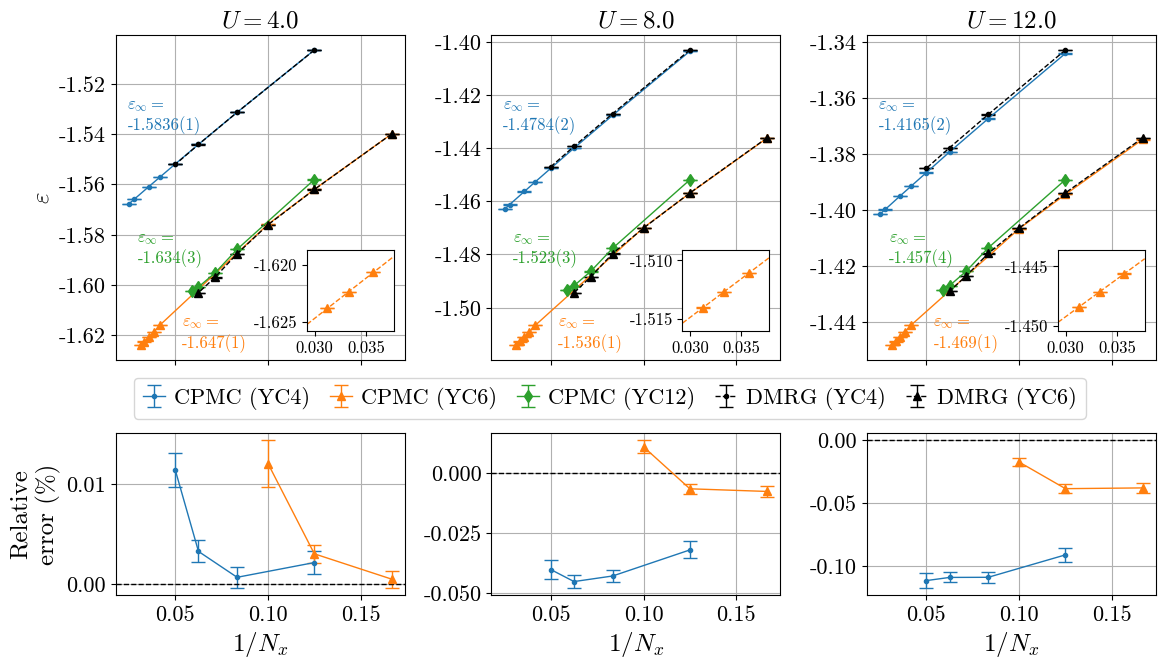

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharex=True, 
                        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.3, 'wspace': 0.3})
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
markers = ['.', '^', 's', 'd']

# CPMC
start = 1
ny = 4
for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_arr_4[iU]
    except: continue
    if df_cpmc is None: continue
    n_sites = ny * df_cpmc.index

    mask = df_cpmc['trial'] == 'fe'
    print()
    print(df_cpmc.index[mask][start:])
    x = 1. / df_cpmc.index[mask]
    y = (df_cpmc['e_cpmc'] / n_sites)[mask]
    yerr = (df_cpmc['err_cpmc'] / n_sites)[mask]
    
    ax = axs[0][iU]
    eb = ax.errorbar(x[start:], y.iloc[start:], yerr.iloc[start:], marker=markers[0], lw=1, capsize=5, 
                     label='CPMC ' + r'(YC4)')

    e_infty = npz_cpmc_4['e_infty'][iU]
    e_infty_err = npz_cpmc_4['e_infty_toterr'][iU]
    s = format_val_err(e_infty, e_infty_err, err_sigfigs=1, style="paren")
    print(e_infty, e_infty_err)
    ax.text(
        0.04, 0.75, 
        # fr"${e_infty:.4f}$" + "\n" + fr"$\pm{e_infty_err:.4f}$",
        r'$\varepsilon_{\infty} = $' + '\n' + s,
        transform=ax.transAxes,
        color=eb.lines[0].get_color(),
        va="center", ha="left",
        fontsize=12
    )

    # ax.set_xlim(ax.get_xlim())
    # ax.set_xticks(1./df_cpmc.index[start:])
    # ax.set_xticklabels(np.rint(df_cpmc.index[start:]).astype(int))

start = 0
ny = 6
for iU, U in enumerate(U_arr):
    try: df_cpmc = df_cpmc_arr_6[iU]
    except: continue
    if df_cpmc is None: continue
    n_sites = ny * df_cpmc.index

    mask = df_cpmc['trial'] == 'fe'
    print()
    print(df_cpmc.index[mask][start:])
    x = 1. / df_cpmc.index[mask]
    y = (df_cpmc['e_cpmc'] / n_sites)[mask]
    yerr = (df_cpmc['err_cpmc'] / n_sites)[mask]
    
    ax = axs[0][iU]
    eb = ax.errorbar(x[start:], y.iloc[start:], yerr.iloc[start:], marker=markers[1], lw=1, capsize=5, 
                     label='CPMC ' + r'(YC6)')

    e_infty = npz_cpmc_6['e_infty'][iU]
    e_infty_err = npz_cpmc_6['e_infty_toterr'][iU]
    s = format_val_err(e_infty, e_infty_err, err_sigfigs=1, style="paren")
    print(e_infty, e_infty_err)
    ax.text(
        0.23, 0.08, 
        # fr"${e_infty:.4f}$" + "\n" + fr"$\pm{e_infty_err:.4f}$",
        r'$\varepsilon_{\infty} = $' + '\n' + s,
        transform=ax.transAxes,
        color=eb.lines[0].get_color(),
        va="center", ha="left",
        fontsize=12
    )
    
    # sub region of the original image
    idx1, idx2 = 32, 28
    delta = 2e-3
    _x = x[x <= 1./ idx2 + delta]
    _y = y.iloc[x <= 1./ idx2 + delta]
    _yerr = yerr.iloc[x <= 1./ idx2 + delta]

    res = scipy.stats.linregress(_x, _y)
    _xfit = np.linspace(1./idx1 - delta, 1./idx2 + delta, 10)
    _yfit = linear(_xfit, res.slope, res.intercept)

    axins = inset_axes(
        ax, 
        width="50%", height="50%",
        loc='lower right', bbox_to_anchor=(0.4, 0.055, 0.6, 0.5), bbox_transform=ax.transAxes
    )
    axins.errorbar(_x, _y, _yerr, marker=markers[1], lw=1, capsize=5, color=colors[1], linestyle="none")
    axins.plot(_xfit, _yfit, ls='--', lw=1, color=colors[1])
    axins.set_xlim(1./idx1-delta, 1./idx2+delta)
    axins.set_ylim(y.loc[idx1]-delta, y.loc[idx2]+delta)
    axins.tick_params(axis="both", labelsize=12)

ny = 12
for iU, U in enumerate(U_arr):
    df_cpmc = df_cpmc_arr_12[iU]
    try: df_cpmc = df_cpmc_arr_12[iU]
    except: continue
    if df_cpmc is None: continue
    n_sites = ny * df_cpmc.index

    mask = df_cpmc['trial'] == 'fe'
    print()
    print(df_cpmc.index[mask][start:])
    x = 1. / df_cpmc.index[mask]
    y = (df_cpmc['e_cpmc'] / n_sites)[mask]
    yerr = (df_cpmc['err_cpmc'] / n_sites)[mask]

    ax = axs[0][iU]
    eb = ax.errorbar(x[start:], y.iloc[start:], yerr.iloc[start:], marker=markers[3], lw=1, capsize=5, 
                label='CPMC ' + r'(YC12)')
    ax.set_title(rf'$U = {{{U}}}$', fontsize=18)

    e_infty = npz_cpmc_12['e_infty'][iU]
    e_infty_err = npz_cpmc_12['e_infty_toterr'][iU]
    s = format_val_err(e_infty, e_infty_err, err_sigfigs=1, style="paren")
    print(e_infty, e_infty_err)
    ax.text(
        0.075, 0.34, 
        # fr"${e_infty:.4f}$" + "\n" + fr"$\pm{e_infty_err:.4f}$",
        r'$\varepsilon_{\infty} = $' + '\n' + s,
        transform=ax.transAxes,
        color=eb.lines[0].get_color(),
        va="center", ha="left",
        fontsize=12
    )

# -----------------------------------------------------------------------------------------------------------------------------------------
# DMRG.
start = 0
ny = 4
for iU, U in enumerate(U_arr):
    try: df_dmrg = df_dmrg_arr_4[iU]
    except: continue
    if df_dmrg is None: continue
    n_sites = ny * df_dmrg.index
    y = df_dmrg['extrap. maxerr -> 0'] / n_sites
    yerr = df_dmrg['total err'] / n_sites
    
    ax = axs[0][iU]
    ax.errorbar(1./df_dmrg.index[start:], y.iloc[start:], yerr.iloc[start:], marker=markers[0], lw=1, capsize=5, 
                color='k', ls='--', label='DMRG ' + r'(YC4)')

start = 0
ny = 6
for iU, U in enumerate(U_arr):
    try: df_dmrg = df_dmrg_arr_6[iU]
    except: continue
    if df_dmrg is None: continue
    n_sites = ny * df_dmrg.index
    y = df_dmrg['extrap. maxerr -> 0'] / n_sites
    yerr = df_dmrg['total err'] / n_sites
    
    ax = axs[0][iU]
    ax.errorbar(1./df_dmrg.index[start:], y.iloc[start:], yerr.iloc[start:], marker=markers[1], lw=1, capsize=5, 
                color='k', ls='--', label='DMRG ' + r'(YC6)')

# -----------------------------------------------------------------------------------------------------------------------------------------
# Diff.
start = 0
for iU, U in enumerate(U_arr):
    try: 
        df_dmrg = df_dmrg_arr_4[iU]
        df_cpmc = df_cpmc_arr_4[iU]
        
    except: continue
    if (df_dmrg is None) or (df_cpmc is None): continue
            
    y_dmrg = df_dmrg['extrap. maxerr -> 0'].iloc[start:]
    yerr_dmrg = df_dmrg['total err'].iloc[start:]

    y_cpmc = df_cpmc['e_cpmc'].iloc[start:]
    yerr_cpmc = df_cpmc['err_cpmc'].iloc[start:]

    diff = y_cpmc - y_dmrg
    pdiff = diff / abs(y_dmrg) * 100
    pdiff_err = 100./y_dmrg**2 * np.sqrt(y_dmrg**2 * yerr_cpmc**2 + y_cpmc**2 * yerr_dmrg**2)
    
    diff = diff.dropna()
    pdiff = pdiff.dropna()
    pdiff_err = pdiff_err.dropna()
    
    ax = axs[1][iU]
    ax.errorbar(1./pdiff.index, pdiff, pdiff_err, marker=markers[0], capsize=5, lw=1)

for iU, U in enumerate(U_arr):
    try: 
        df_dmrg = df_dmrg_arr_6[iU]
        df_cpmc = df_cpmc_arr_6[iU]
        
    except: continue
    if (df_dmrg is None) or (df_cpmc is None): continue
            
    y_dmrg = df_dmrg['extrap. maxerr -> 0']
    yerr_dmrg = df_dmrg['total err']

    y_cpmc = df_cpmc['e_cpmc']
    yerr_cpmc = df_cpmc['err_cpmc']

    diff = y_cpmc - y_dmrg
    pdiff = diff / abs(y_dmrg) * 100
    pdiff_err = 100./y_dmrg**2 * np.sqrt(y_dmrg**2 * yerr_cpmc**2 + y_cpmc**2 * yerr_dmrg**2)
    
    diff = diff.dropna()
    pdiff = pdiff.dropna()
    pdiff_err = pdiff_err.dropna()
    
    ax = axs[1][iU]
    ax.errorbar(1./pdiff.index, pdiff, pdiff_err, marker=markers[1], capsize=5, lw=1)
    ax.axhline(0.0, lw=1, ls='--', color='k')

# -----------------------------------------------------------------------------------------------------------------------------------------
for ax in axs.flatten(): ax.grid()
for i in range(len(U_arr)): axs[1][i].set_xlabel(r'$1 / N_x$')
    
axs[0][0].set_ylabel(r'$\varepsilon$')
axs[1][0].set_ylabel('Relative\nerror (%)')

# Top row.
# Build a single legend spanning all 3 top columns.
# collect unique handles/labels from the top row
handles, labels = [], []
seen = set()
for ax in axs[0]:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll and ll not in seen and not ll.startswith("_"):
            handles.append(hh); labels.append(ll); seen.add(ll)

fig.canvas.draw()
y_bottom_toprow = min(ax.get_position().y0 for ax in axs[0])
legend = fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.48, y_bottom_toprow - 0.1),  # tweak pad as needed
    ncol=5,
    columnspacing=0.9,
    handletextpad=0.4,
    handlelength=1.0,
)

# Bottom row.
# Shrink current axis by 20%
# ax = axs[1][0]
# ax.legend()

plt.tight_layout()
# plt.savefig('../figs/doped_energies_vs_nx.pdf', format='pdf', dpi=300, bbox_inches='tight')